# 04 - Preparacion para modelado

Objetivo: preparar el dataset final para modelado, definir columnas predictoras y realizar un split temporal.

Reglas de esta etapa:
- No se entrenan modelos todavia.
- No se usa split aleatorio.
- No se usa `idpozo` como feature.
- No se usan columnas con leakage si existieran.
- La imputacion, encoding y entrenamiento se haran despues dentro de un pipeline reproducible.

## 1. Importacion de librerias

Se importan librerias de manipulacion de datos, visualizacion y componentes de scikit-learn que se usaran en etapas posteriores. En este notebook no se entrena ningun modelo.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

## 2. Carga del dataset de modelado

Se carga `model_dataset.csv`, generado en el notebook de feature engineering. Este dataset ya contiene el target final con continuidad mensual estricta y features historicas sin leakage.

In [2]:
DATA_PATH = Path("../data/processed/model_dataset.csv")

df_model = pd.read_csv(DATA_PATH, low_memory=False, parse_dates=["fecha_data"])
df_model["fecha_data"] = pd.to_datetime(df_model["fecha_data"], errors="coerce")

print(f"Filas: {df_model.shape[0]:,}")
print(f"Columnas: {df_model.shape[1]:,}")
df_model.head()

Filas: 319,453
Columnas: 77


,idpozo,fecha_data,anio,mes,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,profundidad,coordenadax,coordenaday,produccion_principal,trimestre,semestre,mes_sin,mes_cos,antiguedad_meses,ratio_gas_pet,ratio_agua_pet,ratio_agua_principal,produccion_principal_lag_1,produccion_principal_lag_2,produccion_principal_lag_3,produccion_principal_lag_6,prod_pet_lag_1,prod_pet_lag_3,prod_gas_lag_1,prod_gas_lag_3,prod_agua_lag_1,prod_agua_lag_3,var_principal_1m_pct,var_principal_3m_pct,var_pet_1m_pct,var_gas_1m_pct,var_agua_1m_pct,produccion_principal_mm_3,produccion_principal_mm_6,produccion_principal_std_3,produccion_principal_std_6,prod_pet_mm_3,prod_gas_mm_3,prod_agua_mm_3,produccion_principal_acum,prod_pet_acum,prod_gas_acum,prod_agua_acum,flag_prod_principal_cero,flag_prod_pet_cero,flag_prod_gas_cero,flag_prod_agua_cero,flag_pozo_gasifero,flag_pozo_petrolifero,flag_extraccion_efectiva,idempresa,tipoextraccion,tipoestado,tipopozo,empresa,formprod,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,anio_mes,caida_critica
0,3640,2006-03-31,2006,3,30.81,1.73,30.57,0.00,0.00,0.00,0.00,10.42,"2,585.00",-68.45,-37.95,30.81,1,1,1.00,0.00,0,0.06,0.99,0.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.81,30.81,NaN,NaN,30.81,1.73,30.57,30.81,30.81,1.73,30.57,0,0,0,0,0,1,1,PEL,Bombeo Mecánico,Extracción Efectiva,Petrolífero,PETROLERA ENTRE LOMAS S.A.,VMUT,vaca muerta,ELO,ENTRE LOMAS,ECL,EL CARACOL,NEUQUINA,Neuquén,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-03,0
1,3640,2006-04-30,2006,4,76.61,3.71,46.48,0.00,0.00,0.00,0.00,30.00,"2,585.00",-68.45,-37.95,76.61,2,1,0.87,-0.50,1,0.05,0.61,0.61,30.81,NaN,NaN,NaN,30.81,NaN,1.73,NaN,30.57,NaN,148.67,NaN,148.67,114.50,52.04,53.71,53.71,32.39,32.39,53.71,2.72,38.52,107.42,107.42,5.44,77.05,0,0,0,0,0,1,1,PEL,Bombeo Mecánico,Extracción Efectiva,Petrolífero,PETROLERA ENTRE LOMAS S.A.,VMUT,vaca muerta,ELO,ENTRE LOMAS,ECL,EL CARACOL,NEUQUINA,Neuquén,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-04,0
2,3640,2006-05-31,2006,5,63.27,4.20,50.54,0.00,0.00,0.00,0.00,30.92,"2,585.00",-68.45,-37.95,63.27,2,1,0.50,-0.87,2,0.07,0.80,0.80,76.61,30.81,NaN,NaN,76.61,NaN,3.71,NaN,46.48,NaN,-17.41,NaN,-17.41,13.17,8.73,56.90,56.90,23.56,23.56,56.90,3.22,42.53,170.69,170.69,9.65,127.58,0,0,0,0,0,1,1,PEL,Bombeo Mecánico,Extracción Efectiva,Petrolífero,PETROLERA ENTRE LOMAS S.A.,VMUT,vaca muerta,ELO,ENTRE LOMAS,ECL,EL CARACOL,NEUQUINA,Neuquén,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-05,0
3,3640,2006-06-30,2006,6,55.04,4.37,52.06,0.00,0.00,0.00,0.00,29.99,"2,585.00",-68.45,-37.95,55.04,2,1,0.00,-1.00,3,0.08,0.95,0.95,63.27,76.61,30.81,NaN,63.27,30.81,4.20,1.73,50.54,30.57,-13.01,78.66,-13.01,4.07,3.02,64.98,56.43,10.88,19.26,64.98,4.10,49.69,225.73,225.73,14.02,179.65,0,0,0,0,0,1,1,PEL,Bombeo Mecánico,Extracción Efectiva,Petrolífero,PETROLERA ENTRE LOMAS S.A.,VMUT,vaca muerta,ELO,ENTRE LOMAS,ECL,EL CARACOL,NEUQUINA,Neuquén,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-06,0
4,3640,2006-07-31,2006,7,58.86,3.73,45.72,0.00,0.00,0.00,0.00,30.99,"2,585.00",-68.45,-37.95,58.86,3,2,-0.50,-0.87,4,0.06,0.78,0.78,55.04,63.27,76.61,NaN,55.04,76.61,4.37,3.71,52.06,46.48,6.94,-23.17,6.94,-14.66,-12.19,59.06,56.92,4.12,16.71,59.06,4.10,49.44,284.60,284.60,17.75,225.37,0,0,0,0,0,1,1,PEL,Bombeo Mecánico,Extracción Efectiva,Petrolífero,PETROLERA ENTRE LOMAS S.A.,VMUT,vaca muerta,ELO,ENTRE LOMAS,ECL,EL CARACOL,NEUQUINA,Neuquén,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-07,1


## 3. Definicion de target, identificadores y columnas prohibidas

`idpozo` y `fecha_data` se conservan para trazabilidad y split temporal, pero no se usan como features. Tambien se revisa si existen columnas futuras o de leakage, aunque el dataset final ya deberia venir sin ellas.

In [3]:
target_col = "caida_critica"
id_cols = ["idpozo", "fecha_data"]

leakage_cols = [
    "produccion_principal_next",
    "fecha_siguiente_observada",
    "gap_meses_hasta_siguiente",
    "var_futura_principal_pct",
    "prod_pet_next",
    "prod_gas_next",
]

high_missing_or_free_text_cols = ["vida_util", "observaciones"]

leakage_cols_present = [col for col in leakage_cols if col in df_model.columns]
text_or_missing_cols_present = [col for col in high_missing_or_free_text_cols if col in df_model.columns]

excluded_cols = sorted(set(leakage_cols_present + text_or_missing_cols_present))

column_policy_summary = pd.DataFrame(
    {
        "grupo": [
            "target",
            "id_cols_trazabilidad_no_features",
            "leakage_cols_presentes",
            "texto_libre_o_alta_nulidad_presentes",
        ],
        "columnas": [
            [target_col],
            id_cols,
            leakage_cols_present,
            text_or_missing_cols_present,
        ],
    }
)

column_policy_summary

,grupo,columnas
0,target,[caida_critica]
1,id_cols_trazabilidad_no_features,"[idpozo, fecha_data]"
2,leakage_cols_presentes,[]
3,texto_libre_o_alta_nulidad_presentes,[]


## 4. Separacion inicial de features numericas y categoricas

Se excluyen target, identificadores y columnas prohibidas. Luego se separan candidatas numericas y categoricas por tipo de dato.

In [4]:
columns_to_exclude = set([target_col] + id_cols + excluded_cols)

feature_candidates = [col for col in df_model.columns if col not in columns_to_exclude]

numeric_features_all = df_model[feature_candidates].select_dtypes(include=np.number).columns.tolist()
categorical_features_all = df_model[feature_candidates].select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()

initial_feature_summary = pd.DataFrame(
    {
        "tipo": ["features_numericas_candidatas", "features_categoricas_candidatas"],
        "cantidad": [len(numeric_features_all), len(categorical_features_all)],
    }
)

initial_feature_summary

,tipo,cantidad
0,features_numericas_candidatas,55
1,features_categoricas_candidatas,19


## 5. Cardinalidad de variables categoricas

Para el modelo inicial se usaran solo categoricas de baja cardinalidad. Las variables de alta cardinalidad se dejan fuera para evitar una primera matriz de modelado demasiado dispersa y dificil de explicar.

In [5]:
categorical_cardinality = pd.DataFrame(
    {
        "feature": categorical_features_all,
        "valores_unicos": [df_model[col].nunique(dropna=True) for col in categorical_features_all],
        "pct_nulos": [df_model[col].isna().mean() * 100 for col in categorical_features_all],
    }
).sort_values("valores_unicos", ascending=False)

categorical_cardinality

,feature,valores_unicos,pct_nulos
18,anio_mes,243,0.00
9,idareayacimiento,145,0.00
10,areayacimiento,144,0.00
8,areapermisoconcesion,109,0.00
7,idareapermisoconcesion,109,0.00
0,idempresa,50,0.00
4,empresa,50,0.00
6,formacion,25,0.00
5,formprod,25,0.00
2,tipoestado,12,0.00


In [6]:
LOW_CARDINALITY_MAX = 12

low_cardinality_categorical_features = categorical_cardinality.query(
    "valores_unicos >= 2 and valores_unicos <= @LOW_CARDINALITY_MAX"
)["feature"].tolist()

high_cardinality_categorical_features = categorical_cardinality.query(
    "valores_unicos > @LOW_CARDINALITY_MAX"
)["feature"].tolist()

constant_categorical_features = categorical_cardinality.query("valores_unicos <= 1")["feature"].tolist()

numeric_features = numeric_features_all
categorical_features = low_cardinality_categorical_features

categorical_selection_summary = pd.DataFrame(
    {
        "grupo": [
            "categoricas_usadas_baja_cardinalidad",
            "categoricas_fuera_alta_cardinalidad",
            "categoricas_constantes_fuera",
        ],
        "cantidad": [
            len(categorical_features),
            len(high_cardinality_categorical_features),
            len(constant_categorical_features),
        ],
        "columnas": [
            categorical_features,
            high_cardinality_categorical_features,
            constant_categorical_features,
        ],
    }
)

categorical_selection_summary

,grupo,cantidad,columnas
0,categoricas_usadas_baja_cardinalidad,9,"[tipoestado, tipoextraccion, subclasificacion,..."
1,categoricas_fuera_alta_cardinalidad,9,"[anio_mes, idareayacimiento, areayacimiento, a..."
2,categoricas_constantes_fuera,1,[tipo_de_recurso]


## 6. Matrices X/y sin entrenar modelos

Se define la lista final de features para esta primera etapa de modelado. Todavia no se imputan nulos, no se codifican categoricas y no se entrena ningun modelo.

In [7]:
feature_cols = numeric_features + categorical_features

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

final_feature_summary = pd.DataFrame(
    {
        "metrica": [
            "features_totales",
            "features_numericas",
            "features_categoricas",
            "filas",
        ],
        "valor": [
            len(feature_cols),
            len(numeric_features),
            len(categorical_features),
            len(df_model),
        ],
    }
)

final_feature_summary

,metrica,valor
0,features_totales,64
1,features_numericas,55
2,features_categoricas,9
3,filas,319453


## 7. Split temporal

Se usa `fecha_data` para separar meses antiguos para entrenamiento y meses recientes para test. Esto simula mejor el problema real: entrenar con historia y evaluar en periodos futuros.

In [8]:
df_split = df_model.copy().sort_values("fecha_data").reset_index(drop=True)
df_split["periodo_mes"] = df_split["fecha_data"].dt.to_period("M")

unique_months = np.array(sorted(df_split["periodo_mes"].dropna().unique()))
n_months = len(unique_months)
n_train_months = int(np.floor(n_months * 0.80))

train_months = set(unique_months[:n_train_months])
test_months = set(unique_months[n_train_months:])

train_mask = df_split["periodo_mes"].isin(train_months)
test_mask = df_split["periodo_mes"].isin(test_months)

df_train = df_split.loc[train_mask].copy()
df_test = df_split.loc[test_mask].copy()

X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()
X_test = df_test[feature_cols].copy()
y_test = df_test[target_col].copy()

split_summary = pd.DataFrame(
    {
        "particion": ["train", "test"],
        "filas": [len(df_train), len(df_test)],
        "meses": [df_train["periodo_mes"].nunique(), df_test["periodo_mes"].nunique()],
        "fecha_min": [df_train["fecha_data"].min(), df_test["fecha_data"].min()],
        "fecha_max": [df_train["fecha_data"].max(), df_test["fecha_data"].max()],
        "pozos_unicos": [df_train["idpozo"].nunique(), df_test["idpozo"].nunique()],
    }
)

split_summary

,particion,filas,meses,fecha_min,fecha_max,pozos_unicos
0,train,167513,194,2006-01-31,2022-02-28,2952
1,test,151940,49,2022-03-31,2026-03-31,4361


In [9]:
split_target_distribution = pd.concat(
    [
        pd.DataFrame(
            {
                "particion": "train",
                "caida_critica": y_train.value_counts().sort_index().index,
                "cantidad": y_train.value_counts().sort_index().values,
                "porcentaje": (y_train.value_counts(normalize=True).sort_index() * 100).values,
            }
        ),
        pd.DataFrame(
            {
                "particion": "test",
                "caida_critica": y_test.value_counts().sort_index().index,
                "cantidad": y_test.value_counts().sort_index().values,
                "porcentaje": (y_test.value_counts(normalize=True).sort_index() * 100).values,
            }
        ),
    ],
    ignore_index=True,
)

split_target_distribution

,particion,caida_critica,cantidad,porcentaje
0,train,0,149046,88.98
1,train,1,18467,11.02
2,test,0,132677,87.32
3,test,1,19263,12.68


In [10]:
final_modeling_preparation_summary = pd.DataFrame(
    {
        "metrica": [
            "meses_totales",
            "meses_train",
            "meses_test",
            "features_numericas_finales",
            "features_categoricas_finales",
            "features_totales_finales",
        ],
        "valor": [
            n_months,
            len(train_months),
            len(test_months),
            len(numeric_features),
            len(categorical_features),
            len(feature_cols),
        ],
    }
)

final_modeling_preparation_summary

,metrica,valor
0,meses_totales,243
1,meses_train,194
2,meses_test,49
3,features_numericas_finales,55
4,features_categoricas_finales,9
5,features_totales_finales,64


## Preparacion para modelado

- **Split temporal:** se usa split temporal porque el problema busca predecir eventos futuros. Un split aleatorio mezclaria meses antiguos y recientes, generando una evaluacion demasiado optimista y menos realista.
- **Columnas excluidas:** se excluyen el target, `idpozo`, `fecha_data`, columnas de leakage si existieran y columnas de texto libre o alta nulidad como `vida_util` y `observaciones` si estuvieran presentes.
- **Categoricas usadas:** para el modelo inicial se usan variables categoricas de baja cardinalidad, con entre 2 y 12 categorias. Esto mantiene el primer pipeline interpretable y controlado.
- **Categoricas fuera por alta cardinalidad:** se dejan fuera categoricas con mas de 12 valores unicos, como identificadores de area/yacimiento, empresa, formacion y `anio_mes`. Podran revisarse en iteraciones posteriores con encoding especifico.
- **Desbalance de clases:** existe desbalance moderado: la clase positiva `caida_critica = 1` representa cerca del 12% del total. Este punto debera considerarse al elegir metricas, validacion y posibles estrategias de entrenamiento.
- **Estado final:** quedan definidas `X_train`, `X_test`, `y_train` y `y_test`, pero no se entrena ningun modelo todavia. La imputacion, encoding y entrenamiento se realizaran en el siguiente paso dentro de un pipeline.

## Baseline Logistic Regression

En esta seccion se entrena un primer modelo baseline con `LogisticRegression`. Todo el preprocesamiento queda encapsulado en un `Pipeline`: imputacion, escalado de variables numericas y encoding de variables categoricas. Esto evita transformaciones manuales fuera del pipeline y permite reproducir el flujo completo sobre nuevos datos.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Preprocesador y pipeline

Las variables numericas se imputan con mediana y se escalan con `StandardScaler`. Las categoricas se imputan con la moda y se codifican con `OneHotEncoder(handle_unknown="ignore")`, lo que permite manejar categorias nuevas en el conjunto de test. Se usa `class_weight="balanced"` por el desbalance observado en la clase positiva.

In [12]:
leakage_in_features = sorted(set(feature_cols).intersection(leakage_cols))

if leakage_in_features:
    raise ValueError(f"Se detectaron columnas de leakage en las features: {leakage_in_features}")

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

logreg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

logreg_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### Entrenamiento y predicciones

El modelo se ajusta solo con `X_train` e `y_train`, respetando el split temporal ya definido. Luego se generan clases predichas y probabilidades sobre `X_test` para calcular metricas de clasificacion y ROC AUC.

In [13]:
logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)
y_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]

pd.Series(y_pred_logreg, name="prediccion_logreg").value_counts().sort_index()

prediccion_logreg
0    93077
1    58863
Name: count, dtype: int64

### Metricas del baseline

Se calculan metricas generales y metricas orientadas a la clase positiva. En este proyecto, el recall de `caida_critica = 1` es especialmente importante porque los falsos negativos representan meses en los que el modelo no alerta una caida critica futura.

In [14]:
metrics_logreg = pd.DataFrame(
    [
        {
            "modelo": "LogisticRegression_baseline",
            "roc_auc": roc_auc_score(y_test, y_proba_logreg),
            "accuracy": accuracy_score(y_test, y_pred_logreg),
            "precision": precision_score(y_test, y_pred_logreg, zero_division=0),
            "recall": recall_score(y_test, y_pred_logreg, zero_division=0),
            "f1_score": f1_score(y_test, y_pred_logreg, zero_division=0),
            "filas_train": len(X_train),
            "filas_test": len(X_test),
            "features_numericas": len(numeric_features),
            "features_categoricas": len(categorical_features),
        }
    ]
)

metrics_logreg

,modelo,roc_auc,accuracy,precision,recall,f1_score,filas_train,filas_test,features_numericas,features_categoricas
0,LogisticRegression_baseline,0.63,0.62,0.18,0.55,0.27,167513,151940,55,9


In [15]:
classification_report_logreg = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_logreg,
        output_dict=True,
        zero_division=0,
    )
).T

classification_report_logreg

,precision,recall,f1-score,support
0,0.91,0.64,0.75,"132,677.00"
1,0.18,0.55,0.27,"19,263.00"
accuracy,0.62,0.62,0.62,0.62
macro avg,0.54,0.59,0.51,"151,940.00"
weighted avg,0.81,0.62,0.69,"151,940.00"


In [16]:
confusion_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
confusion_matrix_logreg_df = pd.DataFrame(
    confusion_matrix_logreg,
    index=["real_0", "real_1"],
    columns=["pred_0", "pred_1"],
)

false_negatives_logreg = confusion_matrix_logreg_df.loc["real_1", "pred_0"]
false_positives_logreg = confusion_matrix_logreg_df.loc["real_0", "pred_1"]

confusion_matrix_logreg_df

,pred_0,pred_1
real_0,84374,48303
real_1,8703,10560


### Graficos de evaluacion

La matriz de confusion muestra los errores por clase y la curva ROC resume la capacidad del baseline para ordenar casos positivos por probabilidad. Ambos graficos se guardan en `../reports/figures`.

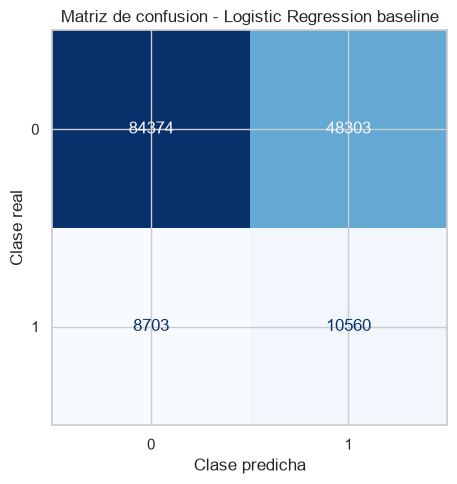

In [17]:
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_logreg,
    display_labels=[0, 1],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusion - Logistic Regression baseline")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
fig.tight_layout()
fig.savefig(figures_dir / "model_logreg_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

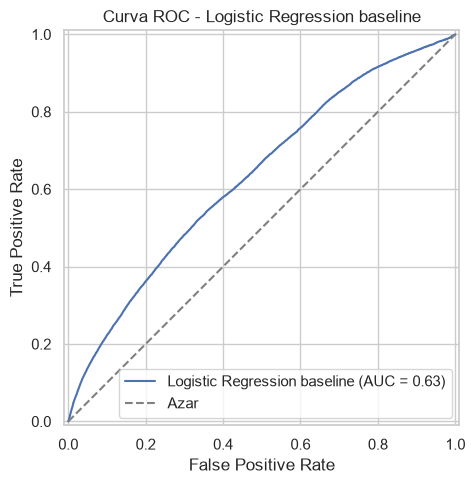

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_logreg,
    name="Logistic Regression baseline",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC - Logistic Regression baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(figures_dir / "model_logreg_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Resultados baseline Logistic Regression

- **Desempeno general:** el baseline obtiene ROC AUC cercano a 0.63 y accuracy cercana a 0.62. Es mejor que una referencia azarosa, pero todavia limitado para una aplicacion operativa.
- **Recall de la clase positiva:** el recall de `caida_critica = 1` queda cerca de 0.55. Es decir, el modelo detecta algo mas de la mitad de las caidas criticas reales del periodo de test.
- **Precision y falsas alarmas:** la precision de la clase positiva queda cerca de 0.18, lo que indica muchos falsos positivos. En la matriz de confusion aparecen 48.303 casos `real_0` clasificados como `pred_1`.
- **Falsos negativos:** quedan 8.703 casos `real_1` clasificados como `pred_0`. Operativamente, representan meses en los que el modelo no anticiparia una caida critica futura.
- **Utilidad como baseline:** Logistic Regression es simple, interpretable y adecuada como punto de partida para validar el pipeline completo, el split temporal y las metricas. El uso de `class_weight="balanced"` ayuda a elevar el recall de la clase minoritaria.
- **Limitaciones:** puede capturar solo relaciones relativamente lineales y depende del encoding de categoricas. En proximas iteraciones convendra comparar contra modelos no lineales y ajustar el umbral de decision segun el costo de falsos negativos y falsos positivos.

## Random Forest Classifier

Se entrena un segundo modelo con `RandomForestClassifier`, manteniendo el mismo split temporal y las mismas features usadas por el baseline. El preprocesamiento sigue dentro de un `Pipeline` para evitar leakage y asegurar que imputacion, encoding y transformaciones se aprendan solo con el conjunto de entrenamiento.

In [19]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

### Pipeline Random Forest

Se usan parametros conservadores para limitar la complejidad del bosque y reducir riesgo de overfitting: profundidad maxima acotada, minimo de muestras por hoja y pesos balanceados por clase.

In [20]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced",
            ),
        ),
    ]
)

rf_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### Entrenamiento y predicciones Random Forest

El modelo se entrena con `X_train` e `y_train`. Luego se calculan clases y probabilidades sobre `X_test`, sin modificar el split temporal ni recalcular features.

In [21]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

pd.Series(y_pred_rf, name="prediccion_rf").value_counts().sort_index()

prediccion_rf
0    97661
1    54279
Name: count, dtype: int64

### Metricas Random Forest

Se calculan las mismas metricas que en Logistic Regression para permitir una comparacion directa entre modelos.

In [22]:
metrics_rf = pd.DataFrame(
    [
        {
            "modelo": "RandomForestClassifier",
            "roc_auc": roc_auc_score(y_test, y_proba_rf),
            "accuracy": accuracy_score(y_test, y_pred_rf),
            "precision": precision_score(y_test, y_pred_rf, zero_division=0),
            "recall": recall_score(y_test, y_pred_rf, zero_division=0),
            "f1_score": f1_score(y_test, y_pred_rf, zero_division=0),
            "filas_train": len(X_train),
            "filas_test": len(X_test),
            "features_numericas": len(numeric_features),
            "features_categoricas": len(categorical_features),
        }
    ]
)

metrics_rf

,modelo,roc_auc,accuracy,precision,recall,f1_score,filas_train,filas_test,features_numericas,features_categoricas
0,RandomForestClassifier,0.67,0.66,0.20,0.55,0.29,167513,151940,55,9


In [23]:
classification_report_rf = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_rf,
        output_dict=True,
        zero_division=0,
    )
).T

classification_report_rf

,precision,recall,f1-score,support
0,0.91,0.67,0.77,"132,677.00"
1,0.20,0.55,0.29,"19,263.00"
accuracy,0.66,0.66,0.66,0.66
macro avg,0.55,0.61,0.53,"151,940.00"
weighted avg,0.82,0.66,0.71,"151,940.00"


In [24]:
confusion_matrix_rf = confusion_matrix(y_test, y_pred_rf)
confusion_matrix_rf_df = pd.DataFrame(
    confusion_matrix_rf,
    index=["real_0", "real_1"],
    columns=["pred_0", "pred_1"],
)

false_negatives_rf = confusion_matrix_rf_df.loc["real_1", "pred_0"]
false_positives_rf = confusion_matrix_rf_df.loc["real_0", "pred_1"]

confusion_matrix_rf_df

,pred_0,pred_1
real_0,89056,43621
real_1,8605,10658


### Graficos Random Forest

Se guardan la matriz de confusion y la curva ROC del Random Forest para documentar su desempeno en el conjunto de test temporal.

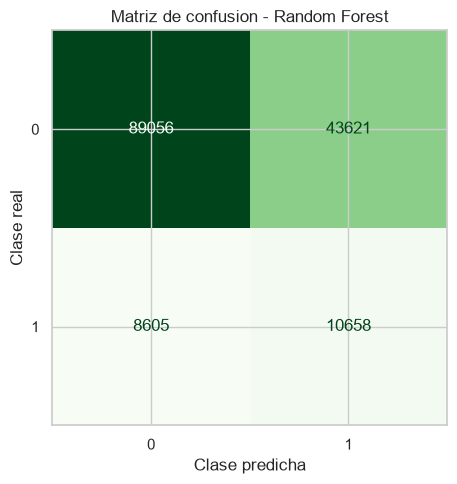

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_rf,
    display_labels=[0, 1],
).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Matriz de confusion - Random Forest")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
fig.tight_layout()
fig.savefig(figures_dir / "model_rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

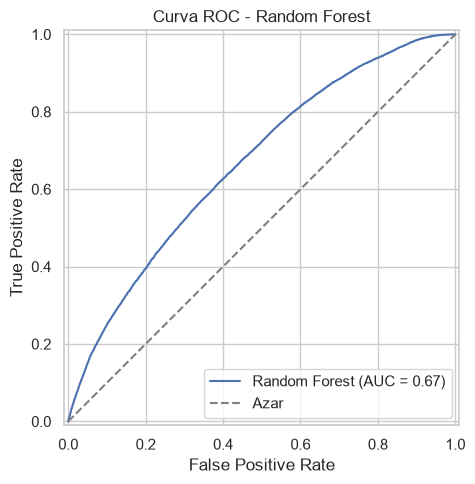

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_rf,
    name="Random Forest",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC - Random Forest")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(figures_dir / "model_rf_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparacion de modelos y guardado

Se comparan ambos modelos con las mismas metricas. Para elegir el mejor pipeline se priorizan ROC AUC, recall de la clase positiva y F1-score como medida de equilibrio entre precision y recall.

In [27]:
model_comparison = pd.concat(
    [
        metrics_logreg.assign(modelo="LogisticRegression"),
        metrics_rf,
    ],
    ignore_index=True,
)[["modelo", "roc_auc", "accuracy", "precision", "recall", "f1_score"]]

model_comparison = model_comparison.rename(
    columns={
        "roc_auc": "ROC AUC",
        "f1_score": "F1-score",
    }
)

model_comparison = model_comparison.sort_values(
    by=["ROC AUC", "recall", "F1-score"],
    ascending=False,
).reset_index(drop=True)

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)
metrics_path = reports_dir / "model_metrics.csv"
model_comparison.to_csv(metrics_path, index=False)

model_comparison

,modelo,ROC AUC,accuracy,precision,recall,F1-score
0,RandomForestClassifier,0.67,0.66,0.20,0.55,0.29
1,LogisticRegression,0.63,0.62,0.18,0.55,0.27


In [28]:
best_model_name = model_comparison.loc[0, "modelo"]

if best_model_name == "RandomForestClassifier":
    best_pipeline = rf_model
else:
    best_pipeline = logreg_model

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "modelo_clasificacion_caida_critica.joblib"
joblib.dump(best_pipeline, best_model_path)

best_model_summary = pd.DataFrame(
    {
        "metrica": [
            "mejor_modelo",
            "criterio_principal",
            "archivo_metricas",
            "archivo_modelo",
        ],
        "valor": [
            best_model_name,
            "ROC AUC, recall clase positiva y F1-score",
            str(metrics_path),
            str(best_model_path),
        ],
    }
)

best_model_summary

,metrica,valor
0,mejor_modelo,RandomForestClassifier
1,criterio_principal,"ROC AUC, recall clase positiva y F1-score"
2,archivo_metricas,..\reports\model_metrics.csv
3,archivo_modelo,..\models\modelo_clasificacion_caida_critica.j...


## Conclusiones de modelado

- **Modelo con mejor desempeno:** `RandomForestClassifier` funciona mejor que `LogisticRegression` en esta comparacion inicial. Obtiene ROC AUC de 0.667, accuracy de 0.656, precision de 0.196, recall de 0.553 y F1-score de 0.290.
- **Metrica a priorizar:** ROC AUC es util para comparar capacidad general de ranking, pero el recall de `caida_critica = 1` debe mirarse con especial atencion porque el objetivo operativo es anticipar caidas criticas. F1-score ayuda a controlar el equilibrio entre detectar caidas y no generar demasiadas falsas alarmas.
- **Falsos negativos:** en Random Forest quedan 8.605 casos `real_1` clasificados como `pred_0`. Representan pozos-mes con caida critica real que el modelo no anticiparia, por lo que son errores relevantes desde el punto de vista operativo.
- **Desbalance:** sigue habiendo evidencia de desbalance de clases: la clase positiva es minoritaria y la precision positiva se mantiene baja. Por eso se usa `class_weight="balanced"` y no conviene evaluar solo con accuracy.
- **Utilidad inicial:** el modelo es util como primera aproximacion reproducible. Mejora el baseline lineal y valida el dataset, el split temporal, el pipeline de preprocesamiento y las metricas, aunque todavia no deberia interpretarse como modelo operativo final.
- **Modelo guardado:** se guarda el mejor pipeline completo en `../models/modelo_clasificacion_caida_critica.joblib`, incluyendo preprocesamiento y estimador.
- **Mejoras futuras:** probar modelos no lineales adicionales, ajustar umbrales de decision, revisar importancia de variables, evaluar validacion temporal por ventanas y analizar costos relativos de falsos negativos y falsos positivos.

## Interpretabilidad del modelo

Se analiza la importancia de variables del `RandomForestClassifier` elegido. La importancia se calcula sobre las features finales luego del preprocesamiento, por lo que incluye variables numericas originales y variables categoricas codificadas con One Hot Encoding. Esta lectura ayuda a entender que senales usa el modelo, aunque no debe interpretarse como causalidad.

In [29]:
rf_pipeline = rf_model
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_estimator = rf_pipeline.named_steps["model"]

rf_feature_names = pd.Series(rf_preprocessor.get_feature_names_out())
rf_feature_names = (
    rf_feature_names
    .str.replace(r"^num__", "", regex=True)
    .str.replace(r"^cat__", "", regex=True)
)

rf_original_n_jobs = rf_estimator.n_jobs
rf_estimator.n_jobs = 1
try:
    rf_importances = rf_estimator.feature_importances_
finally:
    rf_estimator.n_jobs = rf_original_n_jobs

if len(rf_feature_names) != len(rf_importances):
    raise ValueError("La cantidad de nombres de features no coincide con las importancias del modelo.")

rf_feature_importance = pd.DataFrame(
    {
        "feature": rf_feature_names,
        "importance": rf_importances,
    }
).sort_values("importance", ascending=False).reset_index(drop=True)

rf_feature_importance_top20 = rf_feature_importance.head(20)
rf_feature_importance_top20

,feature,importance
0,tef,0.07
1,produccion_principal_std_3,0.05
2,coordenaday,0.05
3,produccion_principal_std_6,0.04
4,anio,0.03
5,prod_gas_acum,0.03
6,var_principal_1m_pct,0.03
7,coordenadax,0.03
8,produccion_principal_acum,0.03
9,var_gas_1m_pct,0.03


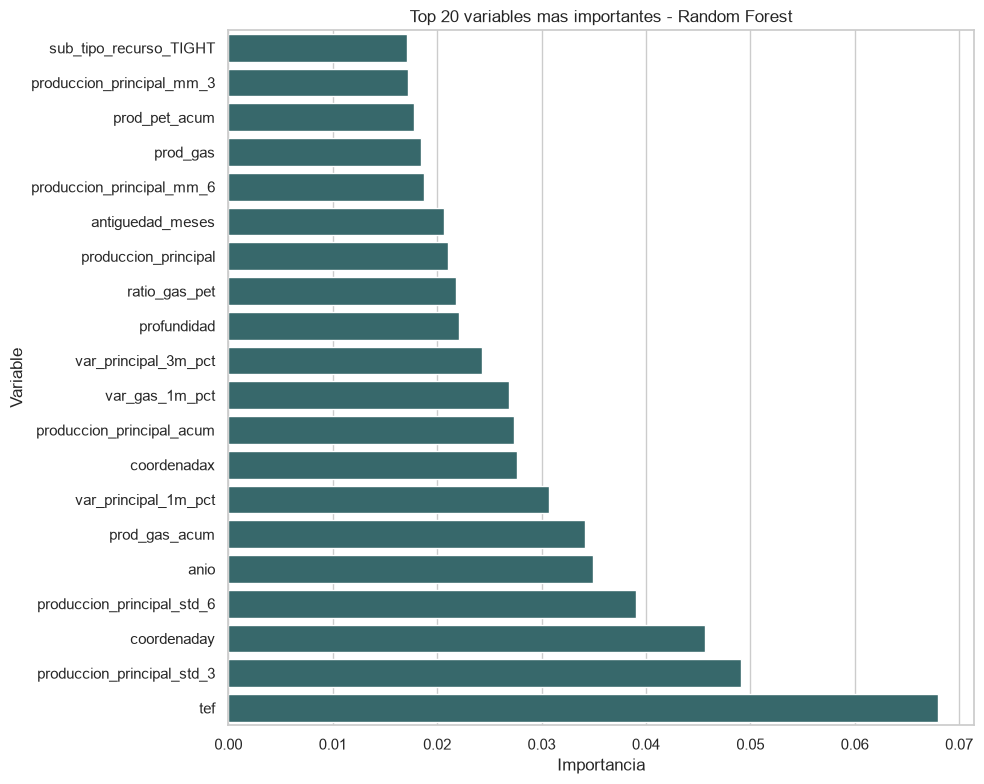

In [30]:
plot_importance_top20 = rf_feature_importance_top20.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=plot_importance_top20,
    x="importance",
    y="feature",
    ax=ax,
    color="#2f6f73",
)
ax.set_title("Top 20 variables mas importantes - Random Forest")
ax.set_xlabel("Importancia")
ax.set_ylabel("Variable")
fig.tight_layout()

rf_importance_path = figures_dir / "rf_feature_importance_top20.png"
fig.savefig(rf_importance_path, dpi=150, bbox_inches="tight")
plt.show()

### Conclusion breve de interpretabilidad

- **Variables dominantes:** entre las variables mas importantes aparecen principalmente variables numericas de produccion, historia productiva y comportamiento reciente del pozo: `tef`, desvios moviles de `produccion_principal`, acumulados, variaciones historicas, produccion actual, antiguedad y medias moviles.
- **Variables temporales y geograficas:** tambien aparecen `anio`, `coordenadax`, `coordenaday` y `profundidad`, lo que sugiere que el modelo aprovecha informacion temporal, espacial y tecnica del pozo.
- **Variables categoricas:** dentro del top 20 aparece al menos una variable codificada de recurso, como `sub_tipo_recurso_TIGHT`. Esto indica que algunas categorias ayudan a segmentar comportamientos productivos, aunque no dominan la interpretacion inicial.
- **Lectura para el problema:** el modelo parece apoyarse en senales coherentes con una caida critica: variabilidad reciente, nivel productivo actual, acumulados, madurez del pozo y contexto tecnico/geografico.
- **Advertencia metodologica:** la importancia de variables en Random Forest no implica causalidad. Estas variables ayudan a predecir dentro del conjunto evaluado, pero no prueban que una variable cause la caida de produccion.